# What drives the price per square meter in Moscow new buildings?

## Project objective

This project examines how the price per square meter in Moscow new buildings is associated with location, housing class, district, and time.

The analysis focuses on four dimensions:

- distance from the city center;
- housing class;
- district;
- time.

The objective is primarily explanatory rather than predictive. The project aims to identify broad market patterns, compare major property segments, and assess how location, housing class, district, and time are jointly associated with
price per square meter.

### Research Questions

1. How is price per square meter associated with distance from the city center?
2. How do price levels differ across housing classes and between central and peripheral locations?
3. Do housing class and district provide additional information about price beyond distance from the city center?
4. Do price trends over time differ across housing classes?

The workflow combines exploratory data analysis, non-parametric segment comparisons, bootstrap confidence intervals, multiple linear regression, model comparison, and diagnostic analysis.

Because the data are observational, the results are interpreted as associations rather than causal effects. The final regression model is used to explain broad market structure and compare segments, not to produce precise valuations for
individual properties.

# Data and Preproccesing

## Setup and Data Loading

In [1]:
##### Imports #####

# Standard library
import os

# Data processing
import numpy as np
import pandas as pd

# Statistics
from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.multitest import multipletests

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [2]:
##### Configuration #####

# Reproducibility
RANDOM_STATE = 42

# Plot settings
sns.set_theme(style='whitegrid')

N_BOOTSTRAP = 5_000
N_PERMUTATIONS = 5_000
CONFIDENCE_LEVEL = 0.95
CENTER_THRESHOLD = 20
HOUSING_CLASSES = ['economy', 'comfort', 'business', 'premium']

# Formatting
def format_thousands(x):
    return f'{x / 1e3:,.2f}K'

def format_percentage(x):
    return f'{x:.2%}'

In [3]:
##### Data loading #####

new_buildings_path = "/kaggle/input/datasets/sergionefedov/moscow-real-estate-sales-and-rentals-20202026/new_builds.csv"
new_buildings_data = pd.read_csv(new_buildings_path, index_col='id', parse_dates=['date_posted'], date_format="%Y-%m-%d")

## Dataset Description

The dataset contains 8,000 apartment listings in Moscow new residential developments. Each row represents an individual apartment listing published on a particular date.

The dataset includes apartment characteristics, residential complex and developer information, location, construction status, transport accessibility, listing price, and price per square meter.

The main outcome variable is `price_per_sqm`, measured in Russian rubles per square meter.

In [4]:
##### Dataset description #####

print(f'Rows: {new_buildings_data.shape[0]:,}')
print(f'Columns: {new_buildings_data.shape[1]}')

print(
    f"Observation period: "
    f"{new_buildings_data['date_posted'].min():%Y-%m-%d} — "
    f"{new_buildings_data['date_posted'].max():%Y-%m-%d}"
)

print(f"Unique residential complexes: {new_buildings_data['complex_id'].nunique():,}")
print(f"Unique developers: {new_buildings_data['developer'].nunique():,}")

preview_columns = [
    'date_posted',
    'complex_name',
    'developer',
    'complex_class',
    'district',
    'total_area',
    'rooms',
    'to_center_km',
    'price_rub',
    'price_per_sqm'
]

display(new_buildings_data[preview_columns].head())
new_buildings_data.info()

summary = new_buildings_data[['price_per_sqm', 'to_center_km']].describe().T

Rows: 8,000
Columns: 24
Observation period: 2021-01-01 — 2026-04-29
Unique residential complexes: 250
Unique developers: 11


,date_posted,complex_name,developer,complex_class,district,total_area,rooms,to_center_km,price_rub,price_per_sqm
id,,,,,,,,,,
N000001,2023-11-22,Level Residence,PIK,business,Sosenskoye,89.3,4,24.59,22075000,247200
N000002,2021-07-08,Sheremetyevsky Residence,LSR,business,Novo-Peredelkino,75.9,3,21.50,22445000,295700
N000003,2022-02-20,Sheremetyevsky Residence,Etalon,economy,Brateyevo,48.6,1,14.97,7075000,145600
N000004,2025-03-23,Sheremetyevsky Residence,Capital Group,comfort,Voronovskoye,36.5,1,57.96,3011000,82500
N000005,2022-08-05,Prokshino Residence,GK A101,comfort,Krasnopakhorskoye,52.2,1,40.42,4420000,84700


<class 'pandas.core.frame.DataFrame'>
Index: 8000 entries, N000001 to N008000
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date_posted               8000 non-null   datetime64[ns]
 1   complex_id                8000 non-null   object        
 2   complex_name              8000 non-null   object        
 3   developer                 8000 non-null   object        
 4   complex_class             8000 non-null   object        
 5   district                  8000 non-null   object        
 6   okrug                     8000 non-null   object        
 7   lat                       8000 non-null   float64       
 8   lon                       8000 non-null   float64       
 9   total_area                8000 non-null   float64       
 10  rooms                     8000 non-null   int64         
 11  floor                     8000 non-null   int64         
 12  total_floors    

In [5]:
styled = (
    summary
    .rename(index={
        'price_per_sqm': 'Price per sqm, RUB',
        'to_center_km' : 'Distance to center, km'
    })
    .rename(columns={
        'count': 'N',
        'mean' : 'Mean',
        'std'  : 'Std',
        'min'  : 'Min',
        '25%'  : 'Q1',
        '50%'  : 'Median',
        '75%'  : 'Q3',
        'max'  : 'Max'
    })
    .style
)

styled = (
    styled
    .format(format_thousands, subset=pd.IndexSlice[['Price per sqm, RUB'], :])
    .format('{:.2f}', subset=pd.IndexSlice[['Distance to center, km'], :])
    .format('{:,.0f}', subset=pd.IndexSlice[:, ['N']])
)

styled

,N,Mean,Std,Min,Q1,Median,Q3,Max
"Price per sqm, RUB","8,000",256.61K,126.40K,52.70K,171.78K,229.65K,318.62K,813.80K
"Distance to center, km","8,000",17.41,14.50,0.36,8.99,13.69,18.99,70.22


The dataset contains 8,000 observations and 24 variables. No missing values are present. The variables include 7 numeric, 10 categorical, 5 integer, 1 Boolean, and 1 datetime feature.

## Data Quality Checks

In [6]:
##### General data quality check #####

checks = pd.Series({
    'Missing values'             : new_buildings_data.isna().sum().sum(),
    'Full-row duplicates'        : new_buildings_data.duplicated().sum(),
    'Duplicated index values'    : new_buildings_data.index.duplicated().sum(),
    'Non-positive area'          : (new_buildings_data['total_area'] <= 0).sum(),
    'Invalid floor'              :
        (
            new_buildings_data['floor']
            > new_buildings_data['total_floors']
        ).sum(),
    'Non-positive price'         : (new_buildings_data['price_rub'] <= 0).sum(),
    'Non-positive price per sqm' : (new_buildings_data['price_per_sqm'] <= 0).sum(),
    'Negative distance to center': (new_buildings_data['to_center_km'] < 0).sum()
}).to_frame('count')

checks

,count
Missing values,0
Full-row duplicates,0
Duplicated index values,0
Non-positive area,0
Invalid floor,0
Non-positive price,0
Non-positive price per sqm,0
Negative distance to center,0


In [7]:
##### price_per_sqm and price_rub consistency quality check #####

calculated_price_per_sqm = new_buildings_data['price_rub'] / new_buildings_data['total_area']
relative_difference = (
    new_buildings_data['price_per_sqm']
    .sub(calculated_price_per_sqm)
    .abs()
    .div(calculated_price_per_sqm)
)

print(
    'Price-per-sqm discrepancies above 1%:',
    (relative_difference > 0.01).sum()
)

Price-per-sqm discrepancies above 1%: 0


In [8]:
##### complex_class distribution check #####

new_buildings_data['complex_class'].value_counts().to_frame('count').reindex(HOUSING_CLASSES)

,count
complex_class,
economy,2608
comfort,3314
business,1748
premium,330


The dataset contains no missing values, duplicated rows, or duplicated identifiers. All key numeric variables have valid positive values, and apartment floor numbers do not exceed the total number of floors.

The listed price per square meter is consistent with the ratio between the total listing price and apartment area, allowing for rounding differences. The `complex_class` variable contains the four expected housing categories with
no unexpected values.

No observations were removed at this stage. Extreme values are retained and examined further during exploratory analysis because they may represent valid premium or peripheral market segments.

## Feature Preparation

Two derived variables are created for subsequent analysis:

- `location_group` divides listings into central and peripheral locations using a 20 km threshold;
- `month` represents the calendar month of the listing and is used to examine monthly price dynamics.

The continuous distance variable is retained for regression analysis, while `location_group` is used only for segment comparisons.

### Location Groups

To support descriptive and segment-level comparisons, distance from the city center is additionally represented as a binary location group.

A 20 km threshold was selected during preliminary exploration of price patterns across distance ranges. It provides a practical separation between relatively central and more peripheral listings while preserving sufficiently large samples
in both groups.

Listings within 20 km are classified as `center`, while listings beyond 20 km are classified as `outskirts`.

The threshold is used only as a convenient analytical segmentation and should not be interpreted as a precisely estimated market boundary. The original continuous distance variable is retained throughout the analysis and is used in
the regression models.

In [9]:
##### Feature preparation #####

new_buildings_data['location_group'] = np.where(
    new_buildings_data['to_center_km'] <= CENTER_THRESHOLD,
    'center',
    'outskirts'
)

new_buildings_data['month'] = (
    new_buildings_data['date_posted']
    .dt.to_period('M')
    .dt.to_timestamp()
)

new_buildings_data[['date_posted', 'month', 'to_center_km', 'location_group']].head()

,date_posted,month,to_center_km,location_group
id,,,,
N000001,2023-11-22,2023-11-01,24.59,outskirts
N000002,2021-07-08,2021-07-01,21.50,outskirts
N000003,2022-02-20,2022-02-01,14.97,center
N000004,2025-03-23,2025-03-01,57.96,outskirts
N000005,2022-08-05,2022-08-01,40.42,outskirts


In [10]:
new_buildings_data['location_group'].value_counts().to_frame('count')

,count
location_group,
center,6151
outskirts,1849


# Exploratory Data Analysis

The exploratory analysis focuses on the variables most relevant to the project: price per square meter, distance from the city center, housing class, and location group.

The objective is to examine the shape of the target distribution, identify major market segments, and assess whether transformations or interaction terms may be required in subsequent regression models.

### Distribution of Price per Square Meter

The distribution of the target variable is examined in its original and log-transformed forms. The transformation is considered because the original price distribution contains a long upper tail and because a log specification may provide a more suitable scale for subsequent regression analysis.

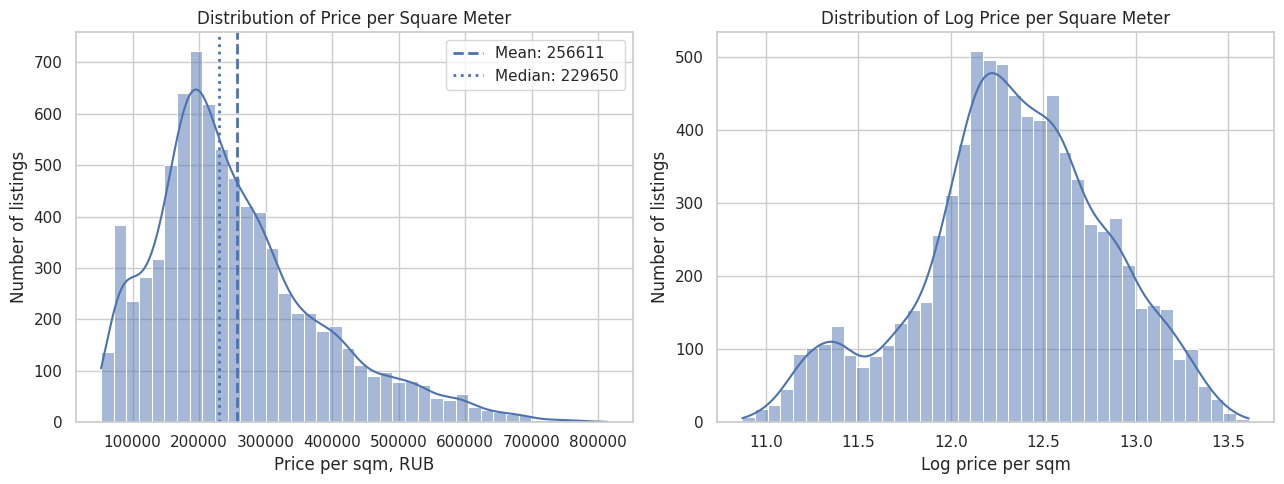

In [11]:
price = new_buildings_data['price_per_sqm']

mean_price = price.mean()
median_price = price.median()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(data=new_buildings_data, x='price_per_sqm', bins=40, kde=True, ax=axes[0])

axes[0].axvline(mean_price,linestyle='--', linewidth=2, label=f'Mean: {mean_price:.0f}')
axes[0].axvline(median_price, linestyle=':', linewidth=2, label=f'Median: {median_price:.0f}')

axes[0].set_title('Distribution of Price per Square Meter')
axes[0].set_xlabel('Price per sqm, RUB')
axes[0].set_ylabel('Number of listings')
axes[0].legend()

log_price = np.log(new_buildings_data['price_per_sqm'])

sns.histplot(x=log_price, bins=40, kde=True, ax=axes[1])

axes[1].set_title('Distribution of Log Price per Square Meter')
axes[1].set_xlabel('Log price per sqm')
axes[1].set_ylabel('Number of listings')

plt.tight_layout()
plt.show()

**Key observations**

- The distribution of `price_per_sqm` is right-skewed, with several high-price observations forming a long upper tail.
- The mean price per square meter is approximately 256,600 RUB, while the median is approximately 229,650 RUB. The higher mean is consistent with the influence of expensive listings.
- The log transformation produces a more symmetric distribution and reduces the visual influence of extreme values.
- However, the log-transformed distribution contains a smaller secondary peak, suggesting that the dataset combines several partially distinct housing market segments.
- High-price observations are retained because they may represent valid business and premium market segments rather than data errors.

### Price and Distance from the City Center

The relationship between price per square meter and distance from the city center is examined in both the original and logarithmic scales. Hexagonal binning is used because individual scatter points would overlap substantially for 8,000 observations.

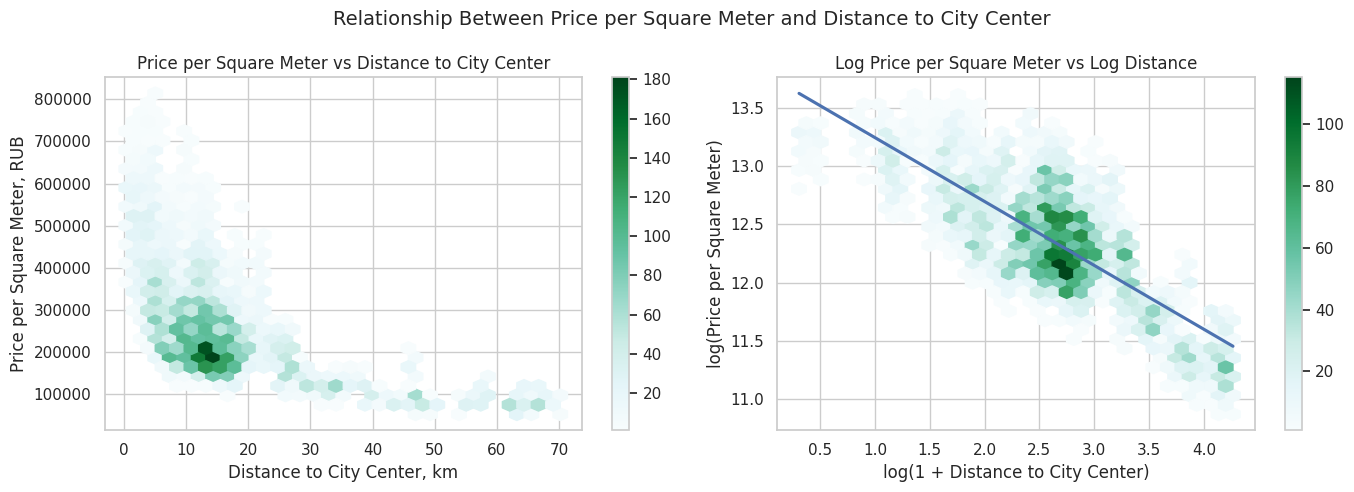

In [12]:
df = new_buildings_data.copy()

df['log_price_per_sqm'] = np.log(df['price_per_sqm'])
df['log_to_center_km'] = np.log1p(df['to_center_km'])

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

df.plot.hexbin(x='to_center_km', y='price_per_sqm', gridsize=30, mincnt=1, ax=axs[0])

axs[0].set_title('Price per Square Meter vs Distance to City Center')
axs[0].set_xlabel('Distance to City Center, km')
axs[0].set_ylabel('Price per Square Meter, RUB')

df.plot.hexbin(x='log_to_center_km', y='log_price_per_sqm', gridsize=30, mincnt=1, ax=axs[1])

sns.regplot(data=df, x='log_to_center_km', y='log_price_per_sqm', scatter=False, ci=None, ax=axs[1])

axs[1].set_title('Log Price per Square Meter vs Log Distance')
axs[1].set_xlabel('log(1 + Distance to City Center)')
axs[1].set_ylabel('log(Price per Square Meter)')

fig.suptitle(
    'Relationship Between Price per Square Meter and Distance to City Center',
    fontsize = 14
)

plt.tight_layout()
plt.show()

**Key observations**

- Price per square meter generally decreases as distance from the city center increases.
- The observations are concentrated approximately 10–20 km from the center, while a smaller peripheral segment extends beyond 40 km.
- The relationship is not fully linear in the original scale: price dispersion is substantially greater near the city center.
- The log-log representation makes the negative association more regular, supporting the comparison of linear and logarithmic distance specifications in the regression section.

### Housing and Location Segments

Price distributions are compared across housing classes and between central and peripheral locations. These variables represent two of the main market segmentation dimensions examined in the project.

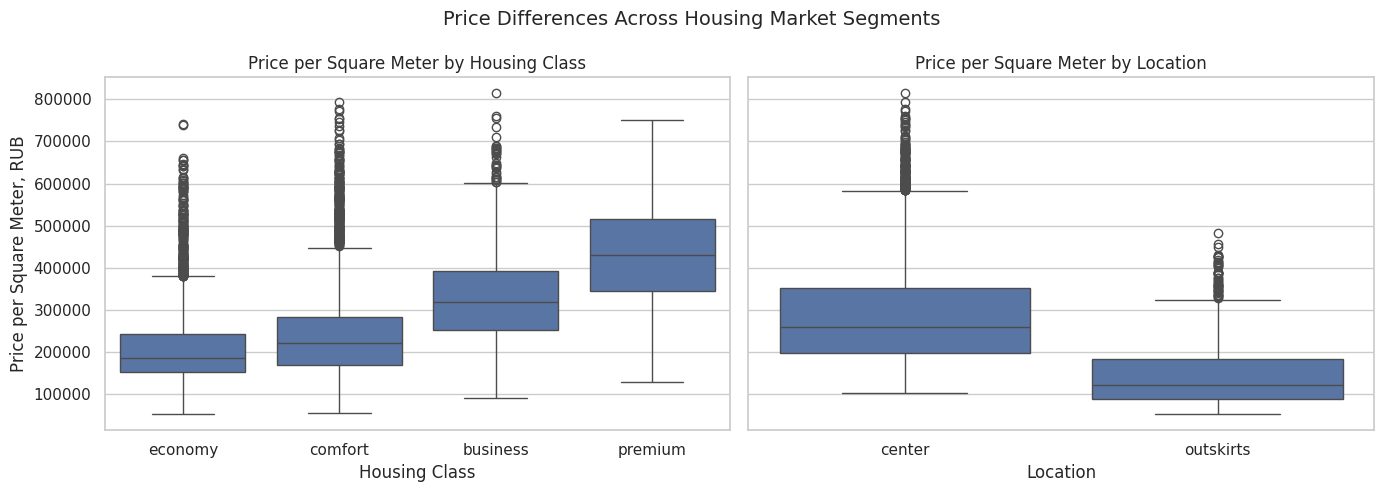

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.boxplot(
    data = new_buildings_data,
    x = 'complex_class',
    y = 'price_per_sqm',
    order = HOUSING_CLASSES,
    ax = axs[0]
)

axs[0].set_title('Price per Square Meter by Housing Class')
axs[0].set_xlabel('Housing Class')
axs[0].set_ylabel('Price per Square Meter, RUB')

sns.boxplot(
    data = new_buildings_data,
    x = 'location_group',
    y = 'price_per_sqm',
    order = ['center', 'outskirts'],
    ax = axs[1]
)

axs[1].set_title('Price per Square Meter by Location')
axs[1].set_xlabel('Location')
axs[1].set_ylabel('')

fig.suptitle(
    'Price Differences Across Housing Market Segments',
    fontsize = 14
)

plt.tight_layout()
plt.show()

**Key observations**

- Median price per square meter increases across housing classes, from economy and comfort to business and premium.
- The distributions overlap, indicating that housing class alone does not fully determine the listing price.
- Listings in the center have a substantially higher median price than listings in the outskirts.
- Price dispersion is also greater in the center, where the dataset contains a wider range of business and premium properties.

### District-Level Price Differences

Median price per square meter is calculated for each district. To avoid unstable rankings based on very small groups, only districts with at least 30 listings are included.

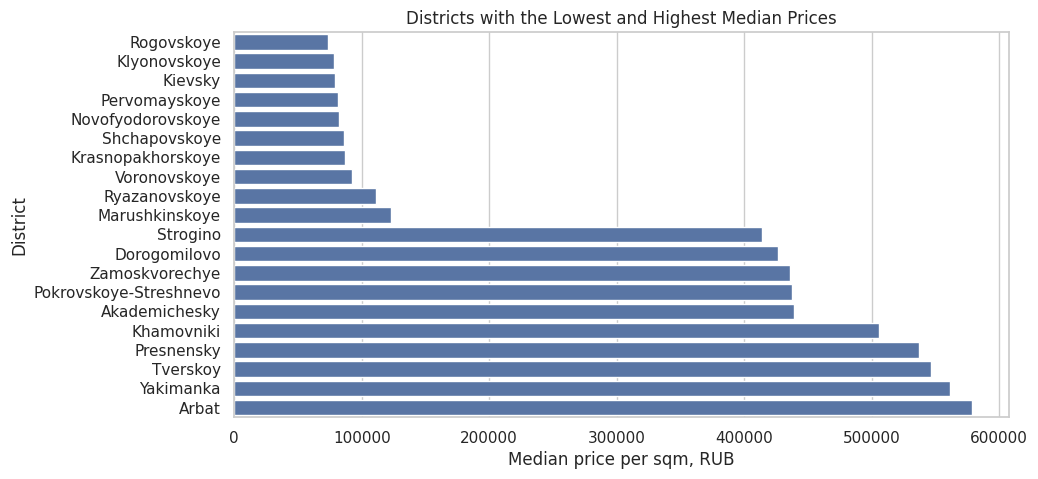

In [14]:
district_summary = (
    new_buildings_data
    .groupby('district')
    .agg(
        median_price = ('price_per_sqm', 'median'),
        n_listings = ('price_per_sqm', 'size')
    )
    .query('n_listings >= 30')
    .sort_values('median_price')
)

district_plot = pd.concat([
    district_summary.head(10),
    district_summary.tail(10)
])

plt.figure(figsize=(10, 5))

sns.barplot(data = district_plot.reset_index(), x='median_price', y='district')

plt.xlabel('Median price per sqm, RUB')
plt.ylabel('District')
plt.title('Districts with the Lowest and Highest Median Prices')
plt.show()

**Key observations**

- Median prices vary substantially across districts.
- District differences remain visible even among locations with broadly similar distance from the city center.
- This suggests that distance alone cannot fully represent location and that district-level categorical effects should be considered in the regression models.

### EDA Summary

The exploratory analysis indicates that the Moscow new-building market is strongly segmented by location and housing class.

Price per square meter has a right-skewed distribution, with a median of approximately 229,650 RUB and a smaller number of substantially more expensive listings. A logarithmic transformation reduces this skewness.

Prices generally decline with distance from the city center, although the relationship is nonlinear and the variability is considerably greater in central locations. Housing class is also strongly associated with price: business and premium properties have higher median prices than economy and comfort properties, but the distributions overlap.

Substantial differences are additionally observed between districts. Therefore, the subsequent analysis should account simultaneously for distance, housing class, and district rather than examining each factor in isolation.

### Monthly Price Trends

Monthly median prices are calculated separately for each housing class. A six-month rolling average is used to reduce short-term variation caused by changes in the composition and number of listings.

The normalized price index divides each class-specific rolling series by its first available value. Therefore, an index of 1.20 corresponds to a 20% increase relative to the beginning of the smoothed series.

In [15]:
def normalize_to_first_valid(series):
    first_valid = series.dropna()

    if first_valid.empty:
        return pd.Series(np.nan, index=series.index)

    return series / first_valid.iloc[0]

In [16]:
ROLLING_WINDOW = 6

monthly_price = (new_buildings_data
    .groupby(['month', 'complex_class'], as_index=False, observed=True)
    .agg(
        median_price_per_sqm = ('price_per_sqm', 'median'),
        n_listings = ('price_per_sqm', 'size')
    ).sort_values(['complex_class', 'month'])
)

monthly_price['rolling_median_price'] = (monthly_price
    .groupby('complex_class')['median_price_per_sqm']
    .transform(
        lambda series: series.rolling(
            window = ROLLING_WINDOW,
            min_periods = ROLLING_WINDOW
        ).mean()
    )
)

monthly_price['price_index'] = (monthly_price
    .groupby('complex_class')['rolling_median_price']
    .transform(normalize_to_first_valid)
)

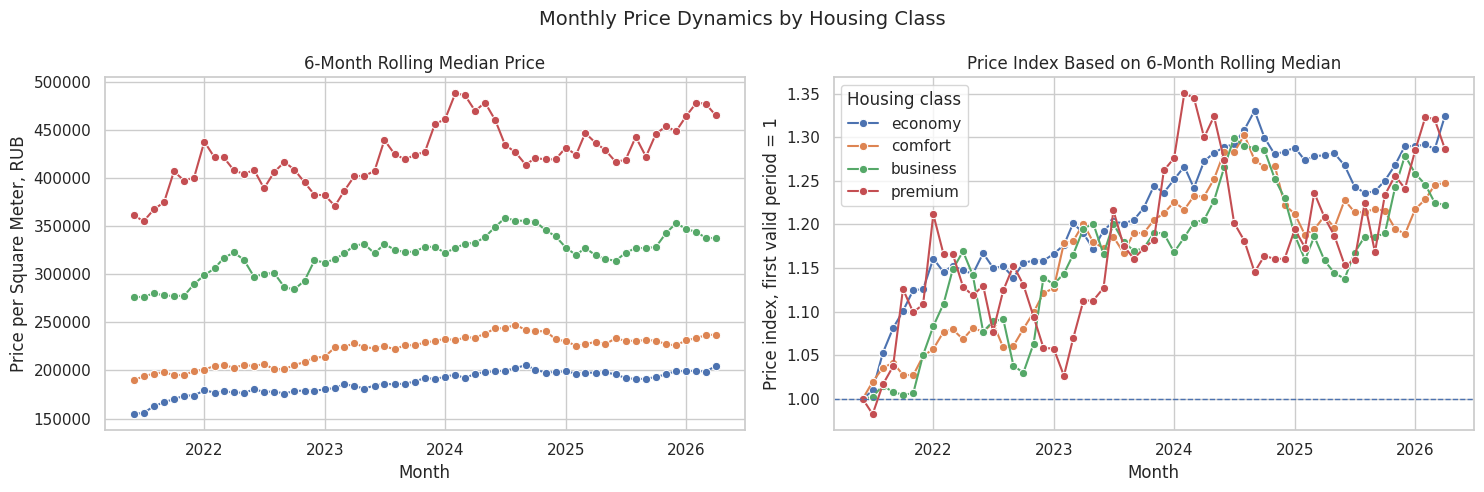

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(
    data = monthly_price,
    x = 'month',
    y = 'rolling_median_price',
    hue = 'complex_class',
    hue_order = HOUSING_CLASSES,
    marker = 'o',
    ax = axs[0],
    legend = False
)

axs[0].set_title(f'{ROLLING_WINDOW}-Month Rolling Median Price')
axs[0].set_xlabel('Month')
axs[0].set_ylabel('Price per Square Meter, RUB')


sns.lineplot(
    data = monthly_price,
    x = 'month',
    y = 'price_index',
    hue = 'complex_class',
    hue_order = HOUSING_CLASSES,
    marker = 'o',
    ax = axs[1]
)

axs[1].axhline(1, linestyle='--', linewidth=1)

axs[1].set_title(f'Price Index Based on {ROLLING_WINDOW}-Month Rolling Median')
axs[1].set_xlabel('Month')
axs[1].set_ylabel('Price index, first valid period = 1')
axs[1].legend(title='Housing class')

fig.suptitle(
    'Monthly Price Dynamics by Housing Class',
    fontsize = 14
)

plt.tight_layout()
plt.show()

**Key observations**

- The price hierarchy between housing classes remains stable throughout the observation period: premium properties have the highest median price, followed by business, comfort, and economy properties.
- Smoothed median prices generally increase over the period for all housing classes, although the trajectories are not monotonic.
- Economy and comfort classes show comparatively stable upward trends.
- The premium segment is substantially more volatile than the other classes. Its short-term movements should be interpreted cautiously because this class contains considerably fewer listings.
- Business-class prices increase over the longer term but also show noticeable periods of decline and recovery.

In [18]:
quarterly_counts = (new_buildings_data
    .assign(quarter=new_buildings_data['date_posted'].dt.to_period('Q'))
    .groupby(['quarter', 'complex_class'], as_index=False, observed=True)
    .agg(
        n_listings = ('price_per_sqm', 'size')
    )
)

quarterly_counts['class_share'] = (
    quarterly_counts['n_listings'] / quarterly_counts
    .groupby('quarter')['n_listings']
    .transform('sum')
)

quarterly_counts['quarter_label'] = quarterly_counts['quarter'].astype(str)

### Listing Volume Over Time

The number of listings is examined by quarter and housing class to assess whether observed price movements may be affected by changes in sample size or market composition.

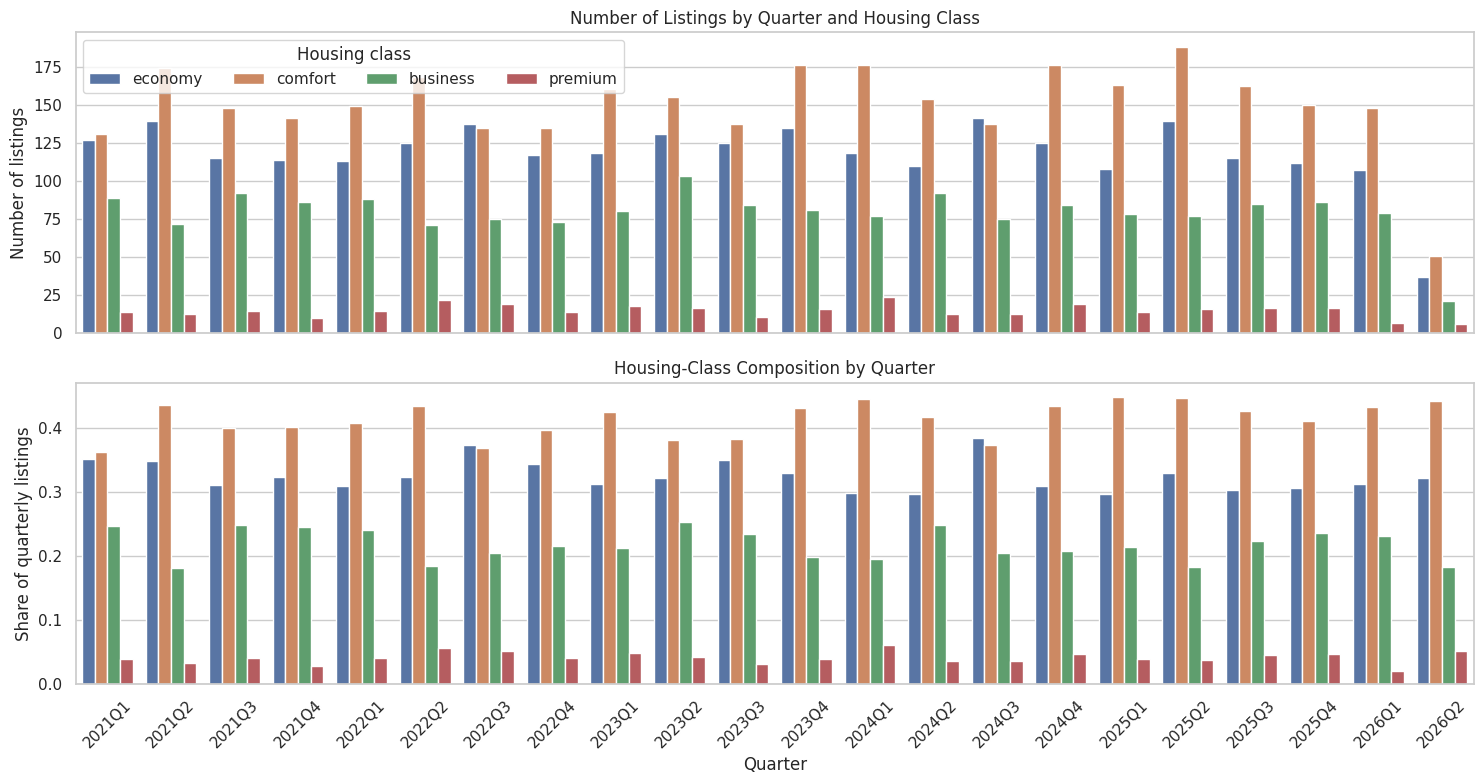

In [19]:
fig, axs = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

sns.barplot(
    data = quarterly_counts,
    x = 'quarter_label',
    y = 'n_listings',
    hue = 'complex_class',
    hue_order = HOUSING_CLASSES,
    ax = axs[0]
)

axs[0].set_title('Number of Listings by Quarter and Housing Class')
axs[0].set_xlabel('')
axs[0].set_ylabel('Number of listings')
axs[0].legend(title='Housing class', ncol=4)


sns.barplot(
    data = quarterly_counts,
    x = 'quarter_label',
    y = 'class_share',
    hue = 'complex_class',
    hue_order = HOUSING_CLASSES,
    ax = axs[1],
    legend = False
)

axs[1].set_title('Housing-Class Composition by Quarter')
axs[1].set_xlabel('Quarter')
axs[1].set_ylabel('Share of quarterly listings')

axs[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Key observations**

- Comfort-class listings form the largest group during most quarters, while premium listings are consistently the least represented.
- The relative composition of the dataset is broadly stable over time, with comfort and economy listings accounting for most observations.
- The small premium sample helps explain the higher volatility of its monthly median price.
- The final quarter contains substantially fewer observations and is incomplete; price estimates for this period should therefore be interpreted with caution.

### Temporal EDA Summary

Median prices per square meter generally increase over the observation period, while the relative ordering of housing classes remains stable.

Economy and comfort segments show the most consistent smoothed growth. Business and especially premium properties exhibit stronger short-term fluctuations. The volatility of the premium series is partly associated with its substantially smaller number of monthly and quarterly observations.

The temporal patterns also differ across housing classes, suggesting that a single common time trend may be insufficient. This motivates testing an interaction between time and housing class in the regression analysis.

# Segment Analysis

## Center vs Outskirts by Housing Class

This section examines whether price per square meter differs between central and peripheral locations overall and within each housing class.

Because the price distributions are right-skewed and contain high-price observations, the analysis focuses on median differences. Bootstrap confidence intervals are used to estimate the magnitude and uncertainty of these differences, while the Mann–Whitney U test is used to compare the distributions.

For each comparison, the estimated effect is defined as:

**median price in the center − median price in the outskirts**

Positive values therefore indicate higher prices in central locations.
P-values are adjusted using the Holm method to account for multiple comparisons.

H0: The price distributions are the same in central and peripheral locations within the given housing class.

H1: The price distributions differ between central and peripheral locations.

In [20]:
SEGMENT_ORDER = ['All', 'economy', 'comfort', 'business', 'premium']

def bootstrap_median_difference(
    values_1,
    values_2,
    n_bootstrap = N_BOOTSTRAP,
    seed = RANDOM_STATE
):
    values_1 = pd.Series(values_1).dropna().to_numpy()
    values_2 = pd.Series(values_2).dropna().to_numpy()

    if len(values_1) == 0 or len(values_2) == 0:
        return {
            'median_difference': np.nan,
            'ci_low'           : np.nan,
            'ci_high'          : np.nan,
            'bootstrap_se'     : np.nan
        }

    rng = np.random.default_rng(seed)
    bootstrap_differences = np.empty(n_bootstrap)

    for i in range(n_bootstrap):
        values_1_sample = rng.choice(values_1, size=len(values_1), replace=True)
        values_2_sample = rng.choice(values_2, size=len(values_2), replace=True)

        bootstrap_differences[i] = (np.median(values_1_sample) - np.median(values_2_sample))

    ci_low, ci_high = np.percentile(bootstrap_differences,[2.5, 97.5])

    return {
        'median_difference': np.median(values_1) - np.median(values_2),
        'ci_low'           : ci_low,
        'ci_high'          : ci_high,
        'bootstrap_se'     : bootstrap_differences.std(ddof=1)
    }

The distributions are first compared visually across housing classes. Outlier markers are hidden for readability, while all observations remain included in the subsequent statistical analysis.

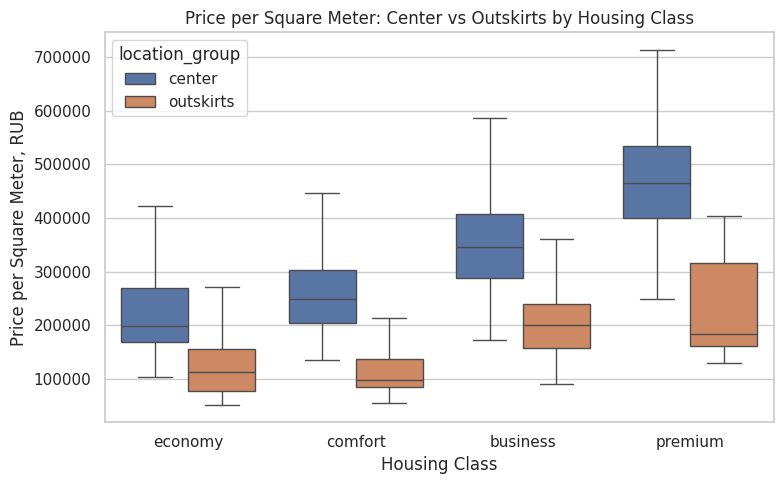

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data = new_buildings_data,
    x = 'complex_class',
    y = 'price_per_sqm',
    hue = 'location_group',
    order = HOUSING_CLASSES,
    hue_order = ['center', 'outskirts'],
    showfliers = False,
    ax = ax
)

ax.set_title('Price per Square Meter: Center vs Outskirts by Housing Class')
ax.set_xlabel('Housing Class')
ax.set_ylabel('Price per Square Meter, RUB')

plt.tight_layout()
plt.show()

The boxplots indicate consistently higher central prices across all housing classes. Descriptive statistics are calculated next to quantify the median levels and group sizes.

In [22]:
segment_summary = (new_buildings_data
    .groupby(['complex_class', 'location_group'], observed=True)
    .agg(
        n_listings = ('price_per_sqm', 'size'),
        mean_price = ('price_per_sqm', 'mean'),
        median_price = ('price_per_sqm', 'median'),
        q25 = ('price_per_sqm', lambda x: x.quantile(0.25)),
        q75 = ('price_per_sqm', lambda x: x.quantile(0.75))
    ).reset_index()
)

segment_summary['iqr'] = segment_summary['q75'] - segment_summary['q25']

segment_summary['complex_class'] = pd.Categorical(
    segment_summary['complex_class'],
    categories = HOUSING_CLASSES,
    ordered = True
)

segment_summary = (
    segment_summary
    .sort_values(['complex_class', 'location_group'])
    .reset_index(drop=True)
)

In [23]:
segment_summary_display = segment_summary.rename(columns={
    'complex_class'  : 'Complex class',
    'location_group' : 'location',
    'n_listings'     : 'N',
    'mean_price'     : 'Mean price',
    'median_price'   : 'Median price',
    'q25'            : 'Q1',
    'q75'            : 'Q3'
})

f = {
    'Mean price'   : format_thousands,
    'Median price' : format_thousands,
    'Q1'           : format_thousands,
    'Q3'           : format_thousands,
    'iqr'          : format_thousands,
}

segment_summary_display.style.format(f)

,Complex class,location,N,Mean price,Median price,Q1,Q3,iqr
0,economy,center,2022,236.23K,198.10K,169.12K,270.48K,101.35K
1,economy,outskirts,586,126.43K,113.55K,77.45K,156.15K,78.70K
2,comfort,center,2499,278.42K,248.40K,205.30K,303.40K,98.10K
3,comfort,outskirts,815,117.13K,98.80K,84.70K,136.80K,52.10K
4,business,center,1361,359.23K,346.50K,288.70K,408.40K,119.70K
5,business,outskirts,387,208.72K,201.50K,158.10K,240.80K,82.70K
6,premium,center,269,468.05K,465.80K,400.20K,533.60K,133.40K
7,premium,outskirts,61,234.38K,184.30K,162.20K,316.20K,154.00K


To estimate the magnitude and uncertainty of the location difference, the center–outskirts median difference is calculated using bootstrap resampling.

The Mann–Whitney U test is then used to assess whether the price distributions differ between central and peripheral locations. Holm-adjusted p-values are reported because several housing-class comparisons are performed.

In [24]:
comparison_groups = {'All': new_buildings_data}

comparison_groups.update({
    complex_class: new_buildings_data.loc[
        new_buildings_data['complex_class'] == complex_class
    ]
    for complex_class in HOUSING_CLASSES
})


comparison_results = []

for segment, segment_data in comparison_groups.items():

    center_prices = segment_data.loc[
        segment_data['location_group'] == 'center',
        'price_per_sqm'
    ].dropna()

    outskirts_prices = segment_data.loc[
        segment_data['location_group'] == 'outskirts',
        'price_per_sqm'
    ].dropna()

    median_center = center_prices.median()
    median_outskirts = outskirts_prices.median()

    bootstrap_result = bootstrap_median_difference(center_prices, outskirts_prices)

    u_statistic, p_value = stats.mannwhitneyu(
        center_prices,
        outskirts_prices,
        alternative = 'two-sided'
    )

    n_center = len(center_prices)
    n_outskirts = len(outskirts_prices)
    rank_biserial = 2 * u_statistic / (n_center * n_outskirts) - 1

    relative_difference = median_center / median_outskirts - 1

    comparison_results.append({
        'segment': segment,

        'n_center'   : len(center_prices),
        'n_outskirts': len(outskirts_prices),

        'median_center'    : median_center,
        'median_outskirts' : median_outskirts,
        'median_difference': bootstrap_result['median_difference'],

        'relative_difference': relative_difference,

        'ci_low' : bootstrap_result['ci_low'],
        'ci_high': bootstrap_result['ci_high'],

        'bootstrap_se'  : bootstrap_result['bootstrap_se'],
        'mann_whitney_u': u_statistic,
        'p_value'       : p_value,

        'rank_biserial': rank_biserial
    })

segment_comparison = pd.DataFrame(comparison_results)

In [25]:
segment_comparison['p_value_holm'] = np.nan

valid_p_mask = (
    segment_comparison['p_value'].notna()
    & segment_comparison['segment'].ne('All')
)

reject, p_values_holm, _, _ = multipletests(
    segment_comparison.loc[valid_p_mask, 'p_value'],
    method='holm'
)

segment_comparison.loc[valid_p_mask, 'p_value_holm'] = p_values_holm


segment_comparison['segment'] = pd.Categorical(
    segment_comparison['segment'],
    categories = SEGMENT_ORDER,
    ordered = True
)

segment_comparison = segment_comparison.sort_values('segment').reset_index(drop=True)

In [26]:
segment_comparison_display = segment_comparison.rename(
    columns={
        'segment'             : 'Segment',
        'n_center'            : 'N center',
        'n_outskirts'         : 'N outskirts',
        'median_center'       : 'Median center',
        'median_outskirts'    : 'Median outskirts',
        'median_difference'   : 'Median difference',
        'relative_difference' : 'Difference, %',
        'ci_low'              : '95% CI low',
        'ci_high'             : '95% CI high',
        'bootstrap_se'        : 'Bootstrap SE',
        'mann_whitney_u'      : 'Mann–Whitney U',
        'p_value'             : 'p-value',
        'rank_biserial'       : 'Rank-biserial effect',
        'p_value_holm'        : 'Holm-adjusted p'
    }
)

f = {
    'Median center'        : format_thousands,
    'Median outskirts'     : format_thousands,
    'Median difference'    : format_thousands,
    'Difference, %'        : format_percentage,
    '95% CI low'           : format_thousands,
    '95% CI high'          : format_thousands,
    'Bootstrap SE'         : format_thousands,
    'Mann–Whitney U'       : '{:,.0f}',
    'Rank-biserial effect' : '{:.3f}',
    'p-value'              : '{:.3g}',
    'Holm-adjusted p'      : '{:.3g}'
}

segment_comparison_display.style.format(f)

,Segment,N center,N outskirts,Median center,Median outskirts,Median difference,"Difference, %",95% CI low,95% CI high,Bootstrap SE,Mann–Whitney U,p-value,Rank-biserial effect,Holm-adjusted p
0,All,6151,1849,260.40K,122.80K,137.60K,112.05%,132.90K,142.80K,2.51K,"10,070,193",0,0.771,nan
1,economy,2022,586,198.10K,113.55K,84.55K,74.46%,79.10K,89.75K,2.72K,"1,027,332",1.13e-161,0.734,3.38e-161
2,comfort,2499,815,248.40K,98.80K,149.60K,151.42%,142.80K,155.20K,3.15K,"1,955,820",0,0.921,0
3,business,1361,387,346.50K,201.50K,145.00K,71.96%,134.20K,154.80K,5.39K,"475,634",1.13e-129,0.806,2.25e-129
4,premium,269,61,465.80K,184.30K,281.50K,152.74%,178.50K,303.30K,32.49K,"15,791",1.73e-29,0.925,1.73e-29


The estimated median differences and their 95% bootstrap confidence intervals are summarized below.

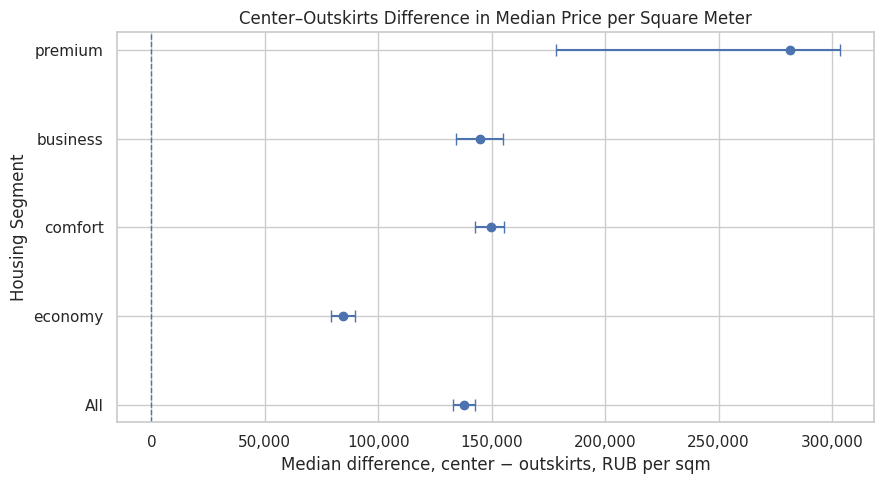

In [27]:
plot_data = segment_comparison[['segment', 'median_difference', 'ci_low', 'ci_high']].dropna().copy()

plot_data['segment'] = plot_data['segment'].astype(str)
plot_data['error_low'] = plot_data['median_difference'] - plot_data['ci_low']
plot_data['error_high'] = plot_data['ci_high'] - plot_data['median_difference']

fig, ax = plt.subplots(figsize=(9, 5))

ax.errorbar(
    x = plot_data['median_difference'],
    y = plot_data['segment'],
    xerr = [plot_data['error_low'], plot_data['error_high']],
    fmt = 'o',
    capsize = 4
)

ax.axvline(0, linestyle='--', linewidth=1)

ax.set_title('Center–Outskirts Difference in Median Price per Square Meter')
ax.set_xlabel('Median difference, center − outskirts, RUB per sqm')
ax.set_ylabel('Housing Segment')

ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

In [28]:
interpretation_table = segment_comparison_display[
    [
        'Segment',
        'Median difference',
        'Difference, %',
        '95% CI low',
        '95% CI high',
        'p-value',
        'Holm-adjusted p'
    ]
].copy()

f = {
    'Median difference' : format_thousands,
    'Difference, %'     : format_percentage,
    '95% CI low'        : format_thousands,
    '95% CI high'       : format_thousands,
    'Holm-adjusted p'   : '{:.3g}',
    'p value'           : '{:.3g}'
}

interpretation_table.style.format(f)

,Segment,Median difference,"Difference, %",95% CI low,95% CI high,p-value,Holm-adjusted p
0,All,137.60K,112.05%,132.90K,142.80K,0.000000,nan
1,economy,84.55K,74.46%,79.10K,89.75K,0.000000,3.38e-161
2,comfort,149.60K,151.42%,142.80K,155.20K,0.000000,0
3,business,145.00K,71.96%,134.20K,154.80K,0.000000,2.25e-129
4,premium,281.50K,152.74%,178.50K,303.30K,0.000000,1.73e-29


**Key observations**

- Median prices are substantially higher in the center for every housing class.
- In central locations, the expected price hierarchy is clear: median prices
  increase from economy to comfort, business, and premium properties.
- This ordering is not preserved in the outskirts: comfort has a lower median
  price than economy, while premium has a lower median price than business.
- The size of the center–outskirts gap differs strongly across housing classes.
  Central prices are approximately 72–74% higher for economy and business
  properties, but about 151–153% higher for comfort and premium properties.
- This heterogeneity suggests that the association between location and price
  is not uniform across housing classes.
- Price dispersion is greatest in business and premium segments, particularly
  in central locations.

### Conclusion

Central properties have higher median prices per square meter both overall and within each housing class. Bootstrap confidence intervals for the estimated median differences do not include zero, and the corresponding Mann–Whitney tests remain significant after Holm correction.

The size of the center premium differs across housing classes, indicating that location and housing class jointly structure the market. These results support including both variables in the subsequent regression analysis.

The estimated differences depend partly on the 20 km threshold used to define the two location groups.

# Regression Analysis

The exploratory and segment analyses show that price per square meter is associated with distance from the city center, housing class, and district.

The regression analysis examines these factors jointly. Several model specifications are compared to determine whether the relationship with distance is better represented in linear or logarithmic form and how much explanatory value is added by housing class and district.

The models are compared using adjusted R², AIC, and BIC. Lower AIC and BIC values indicate a better balance between model fit and complexity.

In [29]:
def compare_models(model_name, model):
    return {
        'Model'       : model_name,
        'R²'          : model.rsquared,
        'Adjusted R²' : model.rsquared_adj,
        'AIC'         : model.aic,
        'BIC'         : model.bic,
        'N parameters': int(model.df_model + 1)
    }


def build_and_compare_models(model_specs, data):
    comparison = []
    fitted_models = {}

    for model_name, formula in model_specs.items():
        model = smf.ols(
            formula = formula,
            data = data
        ).fit()

        fitted_models[model_name] = model
        comparison.append(compare_models(model_name, model))

    comparison = (
        pd.DataFrame(comparison)
        .sort_values('AIC')
        .reset_index(drop=True)
    )

    return comparison, fitted_models

## Distance from the City Center

Pearson correlation is used to describe the linear association between distance and price, while Spearman correlation captures a general monotonic relationship that is less sensitive to skewness and extreme values.

Two baseline regression specifications are considered:

1. a linear distance effect;
2. a logarithmic distance effect.

The logarithmic specification allows the price difference associated with an additional kilometer to be larger near the center and smaller in peripheral locations.

In [30]:
distance = new_buildings_data['to_center_km']
price = new_buildings_data['price_per_sqm']

pearson_r, pearson_p = stats.pearsonr(distance, price)
spearman_r, spearman_p = stats.spearmanr(distance, price)

correlation_table = pd.DataFrame({
    'Method'     : ['Pearson', 'Spearman'],
    'Correlation': [pearson_r, spearman_r],
    'p-value'    : [pearson_p, spearman_p]
})

display(
    correlation_table.style.format({
        'Correlation': '{:.3f}',
        'p-value'    : '{:.3g}'
    })
)

,Method,Correlation,p-value
0,Pearson,-0.620,0
1,Spearman,-0.682,0


Both coefficients indicate a negative association: listings located further from the city center tend to have lower prices per square meter. The difference between the Pearson and Spearman coefficients also suggests that the relationship may not be fully linear.

## Model Specifications

The model sequence is constructed incrementally:

- distance-only models establish the baseline spatial relationship;
- housing-class and district models measure categorical market segmentation;
- combined models examine whether these factors provide complementary information.

In [31]:
model_specs = {
    'Linear distance'                : 'price_per_sqm ~ to_center_km',
    'Log distance'                   : 'price_per_sqm ~ np.log1p(to_center_km)',
    'Housing class'                  : 'price_per_sqm ~ C(complex_class)',
    'District'                       : 'price_per_sqm ~ C(district)',
    'Class + district'               : 'price_per_sqm ~ C(complex_class) + C(district)',
    'Log distance + class'           : 'price_per_sqm ~ np.log1p(to_center_km) + C(complex_class)',
    'Log distance + district'        : 'price_per_sqm ~ np.log1p(to_center_km) + C(district)',
    'Log distance + class + district': (
        'price_per_sqm '
        '~ np.log1p(to_center_km) '
        '+ C(complex_class) '
        '+ C(district)'
    )
}

model_comparison, models = build_and_compare_models(model_specs=model_specs, data=new_buildings_data)
model_comparison['ΔAIC'] = model_comparison['AIC'] - model_comparison['AIC'].min()

f = {
    'R²'          : '{:.3f}',
    'Adjusted R²' : '{:.3f}',
    'AIC'         : '{:,.0f}',
    'ΔAIC'        : '{:,.1f}',
    'BIC'         : '{:,.0f}',
    'N parameters': '{:.0f}'
}

model_comparison.style.format(f)

,Model,R²,Adjusted R²,AIC,BIC,N parameters,ΔAIC
0,Log distance + class + district,0.904,0.903,"192,141","192,930",113,0.0
1,Class + district,0.904,0.902,"192,155","192,938",112,14.6
2,Log distance + district,0.763,0.760,"199,365","200,134",110,"7,224.4"
3,District,0.759,0.756,"199,486","200,247",109,"7,344.9"
4,Log distance + class,0.728,0.727,"200,262","200,297",5,"8,121.8"
5,Log distance,0.508,0.507,"204,994","205,008",2,"12,853.1"
6,Linear distance,0.385,0.385,"206,777","206,791",2,"14,635.9"
7,Housing class,0.188,0.188,"208,994","209,022",4,"16,853.5"


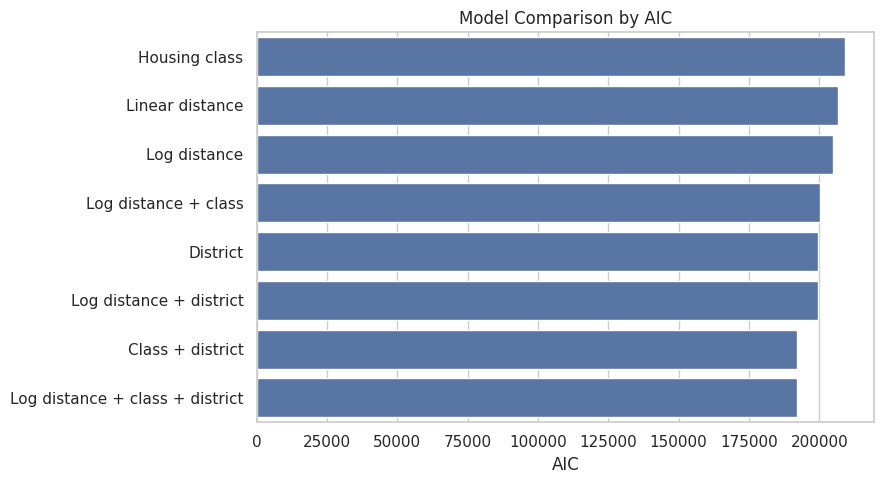

In [32]:
plot_comparison = model_comparison.sort_values('AIC', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data = plot_comparison,
    x = 'AIC',
    y = 'Model',
    ax = ax
)

ax.set_title('Model Comparison by AIC')
ax.set_xlabel('AIC')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

**Key observations**

- The logarithmic distance specification provides a better fit than the simple linear-distance model.
- Housing class and district each explain substantial differences in price per square meter.
- The combined model performs better than models containing only one group of predictors, indicating that distance, housing class, and district capture partly different aspects of market segmentation.
- The model with log distance, housing class, and district provides the best static specification according to AIC and adjusted R².

In [33]:
static_model = models['Log distance + class + district']

static_model_robust = smf.ols(
    formula = (
        'price_per_sqm '
        '~ np.log1p(to_center_km) '
        '+ C(complex_class, Treatment(reference="economy")) '
        '+ C(district)'
    ),
    data = new_buildings_data
).fit(cov_type='HC3')

coefficient_table = pd.DataFrame({
    'Coefficient': static_model_robust.params,
    'Std. error' : static_model_robust.bse,
    'p-value'    : static_model_robust.pvalues,
    'CI low'     : static_model_robust.conf_int()[0],
    'CI high'    : static_model_robust.conf_int()[1]
})

coefficient_table.index.name = 'Term'

main_terms = [
    term
    for term in coefficient_table.index
    if (
        term == 'np.log1p(to_center_km)'
        or 'C(complex_class)' in term
    )
]

f = {
    'Coefficient': '{:,.0f}',
    'Std. error' : '{:,.0f}',
    'p-value'    : '{:.3g}',
    'CI low'     : '{:,.0f}',
    'CI high'    : '{:,.0f}'
}

coefficient_table.loc[main_terms].style.format(f)

,Coefficient,Std. error,p-value,CI low,CI high
Term,,,,,
np.log1p(to_center_km),"-22,376","8,528",0.0087,"-39,091","-5,661"


### Interim Regression Summary

The regression comparison confirms that distance, housing class, and district are all associated with price per square meter.

A logarithmic distance specification fits the data better than a simple linear relationship, consistent with the stronger spatial price gradient near the city center. Housing class and district provide substantial additional explanatory value, and the combined static model outperforms the simpler specifications.

The next step extends this static specification by adding time. A common temporal trend is compared with class-specific time trends to determine whether housing classes follow different price trajectories. The preferred specification is then used for final model interpretation and diagnostics.

## Time and Housing-Class Interaction

The temporal EDA indicates that price dynamics differ across housing classes.
A single common time coefficient may therefore be insufficient.

This section extends the best static model by adding:

1. a common linear time trend;
2. housing-class-specific time trends through an interaction between `month_num` and `complex_class`.

The interaction model allows the monthly rate of price change to differ across housing classes while controlling for district and distance from the city center.

In [34]:
data = new_buildings_data.copy()

month_start = data['month'].min()

data['month_num'] = (
    (data['month'].dt.year - month_start.year) * 12
    + (data['month'].dt.month - month_start.month)
)

In [35]:
time_model_specs = {
    'Static model': (
        'price_per_sqm '
        '~ np.log1p(to_center_km) '
        '+ C(complex_class, Treatment(reference="economy")) '
        '+ C(district)'
    ),

    'Static model + common time trend': (
        'price_per_sqm '
        '~ np.log1p(to_center_km) '
        '+ month_num '
        '+ C(complex_class, Treatment(reference="economy")) '
        '+ C(district)'
    ),

    'Static model + class-specific time trends': (
        'price_per_sqm '
        '~ np.log1p(to_center_km) '
        '+ month_num * C(complex_class, Treatment(reference="economy")) '
        '+ C(district)'
    )
}

time_model_comparison, time_models = build_and_compare_models(model_specs=time_model_specs, data=data)

In [36]:
time_model_comparison['ΔAIC'] = time_model_comparison['AIC'] - time_model_comparison['AIC'].min()

f = {
    'Adjusted R²' : '{:.3f}',
    'AIC'         : '{:,.0f}',
    'ΔAIC'        : '{:.1f}',
    'BIC'         : '{:,.0f}',
    'N parameters': '{:.0f}'
}


time_model_comparison[['Model', 'Adjusted R²', 'AIC', 'ΔAIC', 'BIC', 'N parameters']].style.format(f)

,Model,Adjusted R²,AIC,ΔAIC,BIC,N parameters
0,Static model + class-specific time trends,0.923,"190,217",0.0,"191,034",117
1,Static model + common time trend,0.922,"190,338",121.9,"191,135",114
2,Static model,0.903,"192,141",1924.1,"192,930",113


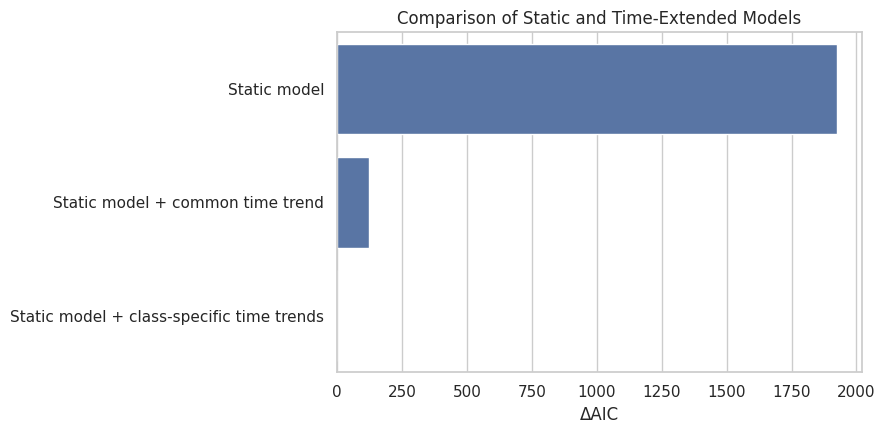

In [37]:
plot_data = time_model_comparison.sort_values('AIC', ascending=False)

fig, ax = plt.subplots(figsize=(9, 4.5))

sns.barplot(
    data = plot_data,
    x = 'ΔAIC',
    y = 'Model',
    ax = ax
)

ax.set_title('Comparison of Static and Time-Extended Models')
ax.set_xlabel('ΔAIC')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

In [38]:
final_model_name = 'Static model + class-specific time trends'

final_model = time_models[final_model_name]
final_formula = time_model_specs[final_model_name]

final_model_robust = smf.ols(
    formula = final_formula,
    data = data
).fit(cov_type='HC3')

confidence_intervals = final_model_robust.conf_int()

final_coefficients = pd.DataFrame({
    'Coefficient': final_model_robust.params,
    'Std. error' : final_model_robust.bse,
    'p-value'    : final_model_robust.pvalues,
    'CI low'     : confidence_intervals[0],
    'CI high'    : confidence_intervals[1]
})

final_coefficients.index.name = 'Term'

final_coefficients = final_coefficients.rename(index={
    'month_num':
        'Economy monthly trend',
    'month_num:C(complex_class, Treatment(reference="economy"))[T.business]':
        'Business trend difference vs economy',
    'month_num:C(complex_class, Treatment(reference="economy"))[T.comfort]':
        'Comfort trend difference vs economy',
    'month_num:C(complex_class, Treatment(reference="economy"))[T.premium]':
        'Premium trend difference vs economy'
})

time_coefficients = final_coefficients.loc[[
    'Economy monthly trend',
    'Business trend difference vs economy',
    'Comfort trend difference vs economy',
    'Premium trend difference vs economy'
]]

f = {
    'Coefficient': '{:,.0f}',
    'Std. error' : '{:,.0f}',
    'p-value'    : '{:.3g}',
    'CI low'     : '{:,.0f}',
    'CI high'    : '{:,.0f}'
}

time_coefficients.style.format(f)

,Coefficient,Std. error,p-value,CI low,CI high
Term,,,,,
Economy monthly trend,770,35,4.05e-110,702,837
Business trend difference vs economy,473,63,8.88e-14,348,597
Comfort trend difference vs economy,127,47,0.00669,35,218
Premium trend difference vs economy,"1,032",168,7.28e-10,704,"1,361"


In [39]:
trend_components = (
    time_coefficients['Coefficient']
    .rename(index={
        'Economy monthly trend': 'economy',
        'Business trend difference vs economy': 'business',
        'Comfort trend difference vs economy': 'comfort',
        'Premium trend difference vs economy': 'premium'
    })
    .reindex(HOUSING_CLASSES)
)

monthly_trends = trend_components.copy()

base_trend = monthly_trends.loc['economy']
non_reference = monthly_trends.index != 'economy'

monthly_trends.loc[non_reference] += base_trend

trend_table = monthly_trends.to_frame(
    'Estimated monthly trend, RUB per sqm'
)

trend_table['Estimated annual trend, RUB per sqm'] = (
    trend_table['Estimated monthly trend, RUB per sqm'] * 12
)

trend_table.style.format({
    'Estimated monthly trend, RUB per sqm': '{:,.0f}',
    'Estimated annual trend, RUB per sqm': '{:,.0f}'
})

,"Estimated monthly trend, RUB per sqm","Estimated annual trend, RUB per sqm"
Term,,
economy,770,"9,237"
comfort,897,"10,759"
business,"1,242","14,908"
premium,"1,802","21,626"


In [52]:
reference_district = data['district'].mode().iloc[0]
reference_distance = data['to_center_km'].median()

months = pd.DataFrame({
    'month_num': np.sort(data['month_num'].unique())
})

classes = pd.DataFrame({
    'complex_class': HOUSING_CLASSES
})

prediction_grid = (
    months
    .merge(classes, how='cross')
    .assign(
        to_center_km=reference_distance,
        district=reference_district
    )
)

prediction_grid['month'] = (
    month_start
    + prediction_grid['month_num'].apply(
        lambda value: pd.DateOffset(months=int(value))
    )
)

prediction_grid['predicted_price_per_sqm'] = final_model.predict(prediction_grid)

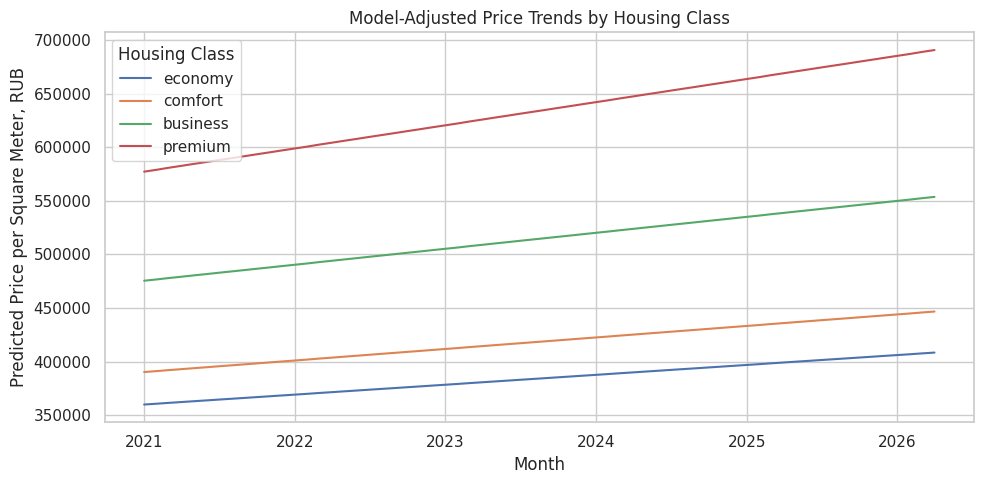

In [53]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data = prediction_grid,
    x = 'month',
    y = 'predicted_price_per_sqm',
    hue = 'complex_class',
    hue_order = HOUSING_CLASSES,
    ax = ax
)

ax.set_title('Model-Adjusted Price Trends by Housing Class')
ax.set_xlabel('Month')
ax.set_ylabel('Predicted Price per Square Meter, RUB')
ax.legend(title='Housing Class')

plt.tight_layout()
plt.show()

Predicted values are calculated for the median distance from the city center and the most frequently observed district. The graph isolates the estimated class-specific time trends while holding location constant.

**Key observations**

- Adding a common time trend improves the static model, indicating that prices change systematically over the observation period.
- Allowing the time trend to differ by housing class provides a further improvement according to AIC and adjusted R².
- The class-specific interaction model is therefore selected as the final specification.
- The estimated trends confirm the temporal EDA: housing classes do not follow identical price trajectories.

# Model Diagnostics

The final regression model is evaluated for multicollinearity, residual structure, and variation in prediction error across housing market segments.

Variance inflation factors are used to assess dependence among predictors. Residual plots are then examined for systematic patterns, non-constant variance, and deviations from normality.

Finally, absolute residuals are summarized by housing class and distance from the city center to identify segments where the model is less accurate.

## Multicollinearity

In [42]:
final_model = time_models['Static model + class-specific time trends']

design_matrix = pd.DataFrame(final_model.model.exog, columns=final_model.model.exog_names)

vif_table = pd.DataFrame({
    'Feature': design_matrix.columns,
    'VIF': [
        variance_inflation_factor(design_matrix.values, i)
        for i in range(design_matrix.shape[1])
    ]
})

vif_table = (
    vif_table
    .query('Feature != "Intercept"')
    .sort_values('VIF', ascending=False)
    .reset_index(drop=True)
)

VIF is calculated from the exact design matrix of the final model. The intercept is excluded from interpretation.

Because district, distance from the center, housing class, and their time interactions describe related market characteristics, some elevated VIF values are expected. They are treated as a diagnostic rather than an automatic reason
to remove substantively important predictors.

In [58]:
pd.set_option('display.max_colwidth', None)
vif_table.head(20).round(2)

,Feature,VIF
0,np.log1p(to_center_km),80.03
1,C(district)[T.Kievsky],17.51
2,C(district)[T.Pervomayskoye],15.42
3,C(district)[T.Novofyodorovskoye],13.37
4,C(district)[T.Voronovskoye],12.57
5,C(district)[T.Zelenograd],12.29
6,C(district)[T.Meshchansky],10.40
7,C(district)[T.Rogovskoye],10.02
8,C(district)[T.Filimonkovskoye],9.51
9,C(district)[T.Ryazanovskoye],9.14


The VIF analysis indicates substantial multicollinearity in the final model.

The highest value is observed for `log1p(to_center_km)` (VIF = 80.03). Several district indicators also have VIF values above 10, including Kievsky, Pervomayskoye, Novofyodorovskoye, Voronovskoye, Zelenograd, Meshchansky, and Rogovskoye.

This result is substantively plausible because district membership and distance from the city center describe overlapping spatial characteristics. Once district fixed effects are included, much of the variation in distance is already represented by the district indicators.

The elevated VIF values imply that some individual coefficients, particularly the coefficient of distance, may be unstable and should not be interpreted as precise isolated effects. However, the variables are retained because distance and district serve different analytical purposes: distance represents a continuous spatial gradient, while district captures local differences not fully explained by distance alone.

Several housing-class and class-by-time interaction terms show moderately elevated VIF values, indicating partial overlap with other predictors in the model. The strongest multicollinearity, however, is associated with logarithmic distance and district indicators.

## Residual Diagnostics

In [44]:
def residual_diagnostics(model, bins=50, alpha=0.12):
    residuals = pd.Series(
        model.resid,
        index = model.model.data.row_labels,
        name = 'residual'
    )

    fitted = pd.Series(model.fittedvalues, index=model.model.data.row_labels, name='fitted')

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    # 1. Residual distribution
    sns.histplot(residuals, bins=bins, kde=True, ax=axes[0, 0])

    axes[0, 0].axvline(0, linestyle='--', linewidth=1)
    axes[0, 0].set_title('Residual Distribution')
    axes[0, 0].set_xlabel('Residual, RUB per sqm')
    axes[0, 0].set_ylabel('Number of listings')

    # 2. Residuals vs fitted
    sns.scatterplot(x=fitted, y=residuals, alpha=alpha, edgecolor=None, ax=axes[0, 1])

    axes[0, 1].axhline(0, linestyle='--', linewidth=1)
    axes[0, 1].set_title('Residuals vs Fitted Values')
    axes[0, 1].set_xlabel('Fitted price per sqm, RUB')
    axes[0, 1].set_ylabel('Residual, RUB per sqm')

    # 3. Scale-location plot
    standardized_residuals = residuals / residuals.std(ddof=1)
    sqrt_abs_standardized = np.sqrt(np.abs(standardized_residuals))

    sns.scatterplot(x=fitted, y=sqrt_abs_standardized, alpha=alpha, edgecolor=None, ax=axes[1, 0])

    axes[1, 0].set_title('Scale–Location Plot')
    axes[1, 0].set_xlabel('Fitted price per sqm, RUB')
    axes[1, 0].set_ylabel('√|Standardized residual|')

    # 4. Q-Q plot
    sm.qqplot(residuals, line='45', fit=True, ax=axes[1, 1])

    axes[1, 1].set_title('Normal Q–Q Plot')

    fig.suptitle('Residual Diagnostics for the Final Model', fontsize=14)

    plt.tight_layout()
    plt.show()

    return residuals, fitted

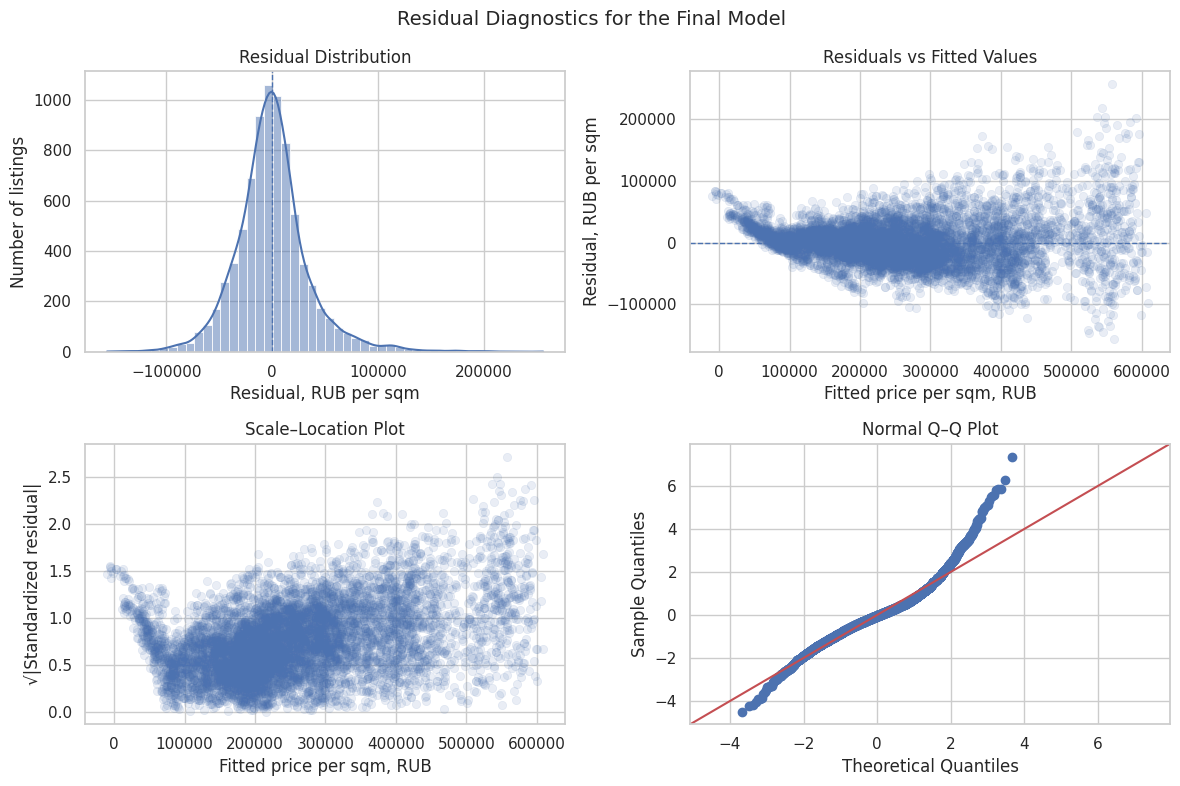

In [45]:
residuals, fitted_values = residual_diagnostics(final_model)

In [46]:
residual_summary = residuals.describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95])

residual_summary.to_frame('Residual').T.style.format(format_thousands)

,count,mean,std,min,5%,25%,50%,75%,95%,max
Residual,8.00K,0.00K,34.72K,-155.81K,-51.19K,-18.91K,-1.22K,15.93K,59.12K,255.86K


In [47]:
mae = np.mean(np.abs(residuals))
rmse = np.sqrt(np.mean(residuals ** 2))

error_metrics = pd.DataFrame({
    'Metric'            : ['MAE', 'RMSE'],
    'Value, RUB per sqm': [mae, rmse]
})

display(
    error_metrics.style.format({
        'Value, RUB per sqm': '{:,.0f}'
    })
)

,Metric,"Value, RUB per sqm"
0,MAE,"24,654"
1,RMSE,"34,717"


The residuals have a mean close to zero, as expected for an OLS model with an intercept. However, their distribution is asymmetric and contains substantial tail deviations.

The median residual is approximately −1,221 RUB per square meter, while 90% of the observations lie approximately between −51,190 and 59,122 RUB per square meter. The residual standard deviation is about 34,719 RUB per square meter.

The residual-versus-fitted plot shows a clear increase in residual dispersion as fitted prices rise. The scale–location plot confirms this pattern, indicating non-constant error variance. The model therefore exhibits heteroskedasticity: prediction uncertainty is considerably greater for higher-priced properties.

The Q–Q plot shows pronounced deviations from the reference line in both tails, especially in the upper tail. The residuals are therefore not normally distributed and contain more extreme observations than would be expected under a normal-error assumption.

### Overall Prediction Error

The model has a mean absolute error of approximately 24,654 RUB per square meter and an RMSE of approximately 34,717 RUB per square meter.

The RMSE is notably higher than the MAE, indicating that a smaller number of large prediction errors have a substantial influence on overall model performance. This is consistent with the long-tailed residual distribution and the greater error dispersion observed for expensive properties.

## Error Analysis by Housing Class

In [59]:
diagnostic_data = data.loc[final_model.model.data.row_labels].copy()

diagnostic_data['residual'] = residuals
diagnostic_data['absolute_residual'] = residuals.abs()
diagnostic_data['fitted_price_per_sqm'] = fitted_values

error_by_class = (
    diagnostic_data
    .groupby('complex_class', observed=True)
    .agg(
        n_listings = ('absolute_residual', 'size'),
        mean_absolute_error = ('absolute_residual', 'mean'),
        median_absolute_error = ('absolute_residual', 'median'),
        residual_std = ('residual', 'std')
    )
    .reindex(HOUSING_CLASSES)
)

error_by_class_display = error_by_class.rename(columns={
    'n_listings'            : 'N',
    'mean_absolute_error'   : 'Mean abs error',
    'median_absolute_error' : 'Median abs error',
    'residual_std'          : 'Residual std'
})

error_by_class_display.style.format('{:,.0f}')

,N,Mean abs error,Median abs error,Residual std
complex_class,,,,
economy,"2,608","22,007","15,938","30,757"
comfort,"3,314","22,058","15,340","31,550"
business,"1,748","30,643","23,752","41,330"
premium,330,"39,913","31,295","52,124"


### Error by Housing Class

Prediction accuracy differs systematically across housing classes.

Economy and comfort properties have similar median absolute errors of approximately 15,938 and 15,340 RUB per square meter, respectively. Errors are larger for business-class properties, with a median absolute error of about 23,752 RUB per square meter.

The premium segment has the highest prediction error: its median absolute error is approximately 31,295 RUB per square meter, while the mean absolute error is about 39,913 RUB per square meter. It also has the largest residual standard
deviation, approximately 52,124 RUB per square meter.

This pattern indicates that the model performs less accurately in higher-priced and more heterogeneous market segments. The premium segment also contains only 330 observations, which limits the stability with which its internal variation
can be estimated.

## Error Analysis by Distance

In [62]:
distance_bins = [0, 10, 20, 30, 40, 50, 60, 70]

diagnostic_data['distance_group'] = pd.cut(
    diagnostic_data['to_center_km'],
    bins = distance_bins,
    include_lowest = True,
    right = False
)

error_by_distance = (
    diagnostic_data
    .groupby('distance_group', observed=True)
    .agg(
        n_listings = ('absolute_residual', 'size'),
        mean_absolute_error = ('absolute_residual', 'mean'),
        median_absolute_error = ('absolute_residual', 'median'),
        residual_std = ('residual', 'std')
    ).reset_index()
)

error_by_distance_display = error_by_distance.rename(columns={
    'distance_group'        : 'Distance',
    'n_listings'            : 'N',
    'mean_absolute_error'   : 'Mean abs error',
    'median_absolute_error' : 'Median abs error',
    'residual_std'          : 'Residual std'
})

f = {
    'Mean abs error'   : '{:,.0f}',
    'Median abs error' : '{:,.0f}',
    'Residual std'     : '{:,.0f}',
}

error_by_distance_display.style.format(f)

,Distance,N,Mean abs error,Median abs error,Residual std
0,"[0, 10)",2438,"36,111","27,653","48,595"
1,"[10, 20)",3713,"20,121","15,499","26,790"
2,"[20, 30)",791,"16,496","11,843","22,351"
3,"[30, 40)",329,"11,095","9,865","13,559"
4,"[40, 50)",295,"24,195","15,200","34,445"
5,"[50, 60)",135,"23,235","22,295","28,942"
6,"[60, 70)",274,"26,086","19,839","32,924"


### Error by Distance from the City Center

Prediction error also varies substantially with distance from the city center.

The highest median absolute error is observed within 10 km of the center: approximately 27,653 RUB per square meter. Error then decreases with distance, reaching its minimum of about 9,865 RUB per square meter in the 30–40 km band.

Beyond 40 km, prediction error increases again. Median absolute errors are approximately 15,200 RUB per square meter at 40–50 km, 22,295 RUB per square meter at 50–60 km, and 19,839 RUB per square meter at 60–70 km.

The high error in central locations likely reflects the greater diversity and price dispersion of central properties, including a larger concentration of business and premium listings. The increase in the outer distance bands may partly reflect smaller sample sizes and local market differences that are not fully captured by the model.

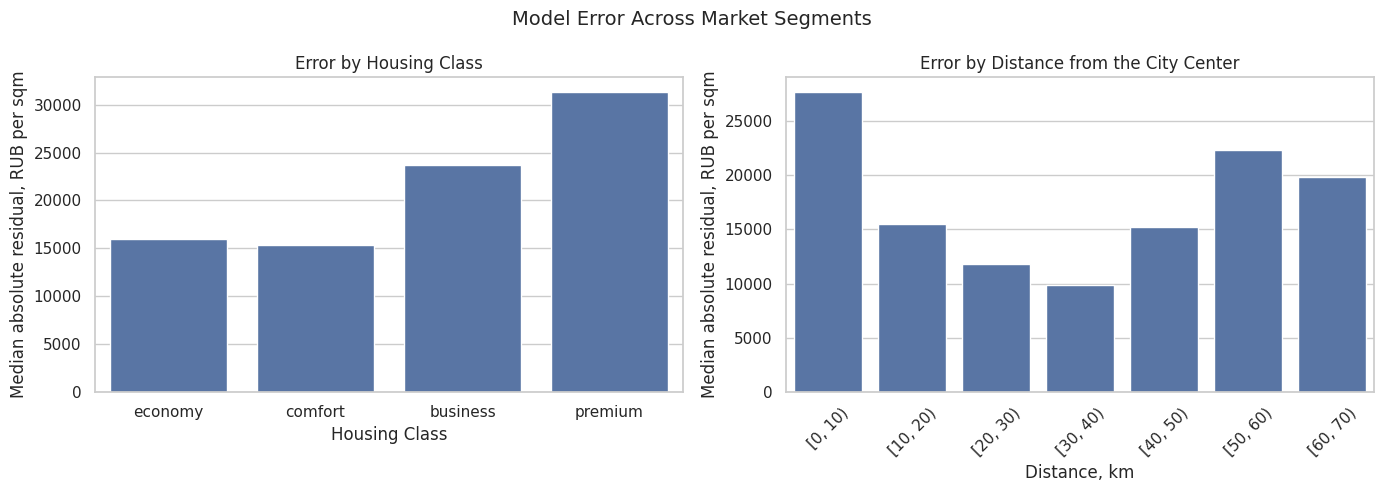

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data = error_by_class,
    x = 'complex_class',
    y = 'median_absolute_error',
    order = HOUSING_CLASSES,
    ax = axes[0]
)

axes[0].set_title('Error by Housing Class')
axes[0].set_xlabel('Housing Class')
axes[0].set_ylabel('Median absolute residual, RUB per sqm')


sns.barplot(
    data = error_by_distance,
    x = 'distance_group',
    y = 'median_absolute_error',
    ax = axes[1]
)

axes[1].set_title('Error by Distance from the City Center')
axes[1].set_xlabel('Distance, km')
axes[1].set_ylabel('Median absolute residual, RUB per sqm')
axes[1].tick_params(axis='x', rotation=45)

fig.suptitle('Model Error Across Market Segments', fontsize=14)

plt.tight_layout()
plt.show()

### Diagnostic Summary

The final model captures the main systematic relationships between price per square meter, location, housing class, district, and time, but the diagnostics reveal several important limitations.

First, substantial multicollinearity is present. The VIF for logarithmic distance is approximately 80, and several district indicators have VIF values above 10. This reflects the strong overlap between district membership and distance from the city center. Consequently, individual spatial coefficients should be interpreted cautiously.

Second, the residual variance is not constant. Both the residual-versus-fitted and scale–location plots show that prediction errors become more dispersed as fitted prices increase. The Q–Q plot also shows pronounced tail deviations,
indicating non-normal residuals and a greater frequency of extreme errors. Robust HC3 standard errors are therefore used for coefficient inference.

The model's overall MAE is approximately 24,654 RUB per square meter, while the RMSE is approximately 34,717 RUB per square meter. The higher RMSE reflects the influence of relatively large prediction errors.

Prediction accuracy is not uniform across market segments. Economy and comfort properties have the lowest median absolute errors, while business and premium properties are predicted less accurately. The premium segment has the highest median absolute error, approximately 31,295 RUB per square meter.

Errors are also largest in the central 0–10 km zone, decline to their minimum at approximately 30–40 km, and increase again in the outer distance bands. This suggests that the model performs best for the more homogeneous middle distance segments and less accurately for highly heterogeneous central properties and sparsely represented peripheral locations.

Overall, the model is useful for identifying broad market patterns, but it should not be treated as a high-precision prediction model for individual listings. Its main limitations are spatial multicollinearity, heteroskedasticity, heavy-tailed residuals, and uneven accuracy across market segments.

# Conclusions and limitations

Price per square meter in Moscow new buildings is jointly associated with location, housing class, district, and time.

Prices generally decline with distance from the city center, while business and premium properties have higher median prices than economy and comfort properties. Central listings are more expensive within every housing class, and district differences remain important even after accounting for distance.

The temporal analysis shows that housing classes follow different price trajectories, so the final regression model includes class-specific time trends.

The model captures the main market-level patterns but has several limitations. Distance and district are strongly collinear, residual variance increases for more expensive properties, and errors are larger in premium, central, and some peripheral segments. The model should therefore be used to explain broad market structure rather than to estimate the exact value of an individual listing.

Overall, no single factor explains price differences on its own. The results support a segmented view of the market in which spatial location, housing class, district, and time provide complementary information.